In [1]:
# ============================================================
# STEP 1: Imports, configuration, and reproducibility
# ============================================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

In [2]:


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42


def set_seed(seed: int = 42) -> None:
    """
    Set random seeds for reproducible experiments.
    """
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # More deterministic CUDA behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------------------------------------------
# Core experiment settings
# ------------------------------------------------------------
LOOKBACK = 180
HORIZONS = [1, 7, 30]

CUTOFF_DATE = pd.Timestamp("2016-01-01")
VAL_FRAC = 0.15

BATCH_SIZE = 64
NUM_WORKERS = 0


print("=" * 60)
print("PatchTST baseline experiment")
print("=" * 60)
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
print(f"Random seed     : {SEED}")
print(f"Lookback        : {LOOKBACK}")
print(f"Horizons        : {HORIZONS}")
print(f"Test cutoff     : {CUTOFF_DATE.date()}")
print(f"Validation frac : {VAL_FRAC}")

PatchTST baseline experiment
PyTorch version : 2.9.1+cpu
Device          : cpu
Random seed     : 42
Lookback        : 180
Horizons        : [1, 7, 30]
Test cutoff     : 2016-01-01
Validation frac : 0.15


In [6]:
# ============================================================
# STEP 2: Load and verify Sirikit reservoir data
# ============================================================

CSV_PATH = (
    "../Level2_5140_1974_Sirikit.csv"
)

df = pd.read_csv(CSV_PATH)

print("Original columns:")
print(df.columns.tolist())


Original columns:
['Date', 'Storage_km3']


In [7]:

# ------------------------------------------------------------
# Keep only the required fields
# ------------------------------------------------------------
required_columns = ["Date", "Storage_km3"]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


df = df[required_columns].copy()

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

df["Storage_km3"] = pd.to_numeric(
    df["Storage_km3"],
    errors="coerce"
)


# ------------------------------------------------------------
# Clean and sort chronologically
# ------------------------------------------------------------
rows_before = len(df)

df = (
    df.dropna(subset=["Date", "Storage_km3"])
      .sort_values("Date")
      .drop_duplicates(subset=["Date"], keep="first")
      .reset_index(drop=True)
)

rows_after = len(df)


# ------------------------------------------------------------
# Verify chronological continuity
# ------------------------------------------------------------
date_differences = df["Date"].diff().dropna()

non_daily_gaps = date_differences[
    date_differences != pd.Timedelta(days=1)
]


print("\n" + "=" * 60)
print("Sirikit dataset summary")
print("=" * 60)

print(f"Rows before cleaning : {rows_before}")
print(f"Rows after cleaning  : {rows_after}")
print(f"Rows removed         : {rows_before - rows_after}")

print(f"Start date           : {df['Date'].min().date()}")
print(f"End date             : {df['Date'].max().date()}")

print(
    f"Storage minimum      : "
    f"{df['Storage_km3'].min():.6f} km³"
)

print(
    f"Storage mean         : "
    f"{df['Storage_km3'].mean():.6f} km³"
)

print(
    f"Storage maximum      : "
    f"{df['Storage_km3'].max():.6f} km³"
)

print(f"Non-daily gaps       : {len(non_daily_gaps)}")


print("\nFirst five rows:")
print(df.head())

print("\nLast five rows:")
print(df.tail())


# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
assert df["Date"].is_monotonic_increasing
assert df["Storage_km3"].notna().all()

if len(non_daily_gaps) > 0:
    print("\nWarning: Date gaps were detected.")
    print(non_daily_gaps.head(10))
else:
    print("\nThe time series is continuous at daily resolution.")


Sirikit dataset summary
Rows before cleaning : 13169
Rows after cleaning  : 13169
Rows removed         : 0
Start date           : 1987-12-12
End date             : 2023-12-31
Storage minimum      : 2.279510 km³
Storage mean         : 5.000871 km³
Storage maximum      : 8.417607 km³
Non-daily gaps       : 0

First five rows:
        Date  Storage_km3
0 1987-12-12     4.064504
1 1987-12-13     4.065823
2 1987-12-14     4.067143
3 1987-12-15     4.068463
4 1987-12-16     4.069783

Last five rows:
            Date  Storage_km3
13164 2023-12-27     5.316066
13165 2023-12-28     5.314915
13166 2023-12-29     5.313879
13167 2023-12-30     5.312958
13168 2023-12-31     5.312153

The time series is continuous at daily resolution.


In [8]:
# ============================================================
# STEP 3: Chronological split + training-only normalization
# ============================================================

# ------------------------------------------------------------
# Chronological split
# ------------------------------------------------------------
train_df = df[df["Date"] < CUTOFF_DATE].copy()
test_df  = df[df["Date"] >= CUTOFF_DATE].copy()


print("=" * 60)
print("Chronological Split")
print("=" * 60)

print(
    f"Train : {train_df['Date'].min().date()} "
    f"→ {train_df['Date'].max().date()}"
)
print(f"Train samples : {len(train_df)}")

print()

print(
    f"Test  : {test_df['Date'].min().date()} "
    f"→ {test_df['Date'].max().date()}"
)
print(f"Test samples  : {len(test_df)}")


# ------------------------------------------------------------
# Fit scaler ONLY on training data
# ------------------------------------------------------------
scaler = StandardScaler()

scaler.fit(train_df[["Storage_km3"]])

train_series = scaler.transform(
    train_df[["Storage_km3"]]
).flatten()

test_series = scaler.transform(
    test_df[["Storage_km3"]]
).flatten()


print("\nScaler Statistics")
print("-" * 60)
print(f"Training mean : {scaler.mean_[0]:.6f}")
print(f"Training std  : {np.sqrt(scaler.var_[0]):.6f}")


print("\nScaled Series Shapes")
print("-" * 60)
print(f"Train : {train_series.shape}")
print(f"Test  : {test_series.shape}")


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------
assert len(train_series) == len(train_df)
assert len(test_series) == len(test_df)

print("\n✓ Chronological split completed successfully.")
print("✓ Training-only normalization completed successfully.")

Chronological Split
Train : 1987-12-12 → 2015-12-31
Train samples : 10247

Test  : 2016-01-01 → 2023-12-31
Test samples  : 2922

Scaler Statistics
------------------------------------------------------------
Training mean : 5.112122
Training std  : 1.189964

Scaled Series Shapes
------------------------------------------------------------
Train : (10247,)
Test  : (2922,)

✓ Chronological split completed successfully.
✓ Training-only normalization completed successfully.


In [9]:
# ============================================================
# STEP 4: Create supervised windows for all forecast horizons
# ============================================================

def make_windows(
    series: np.ndarray,
    lookback: int,
    horizon: int,
    stride: int = 1
):
    """
    Convert a 1D time series into supervised learning windows.

    Parameters
    ----------
    series : np.ndarray
        One-dimensional scaled time series.
    lookback : int
        Number of past observations used as input.
    horizon : int
        Number of future observations predicted directly.
    stride : int
        Step size between consecutive windows.

    Returns
    -------
    X : np.ndarray
        Shape: [num_samples, lookback, 1]
    y : np.ndarray
        Shape:
        - [num_samples, 1] for horizon=1
        - [num_samples, horizon] otherwise
    """
    X, y = [], []

    last_start = len(series) - lookback - horizon + 1

    for start_idx in range(0, last_start, stride):
        input_end = start_idx + lookback
        target_end = input_end + horizon

        X.append(series[start_idx:input_end])
        y.append(series[input_end:target_end])

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    # Add channel dimension for univariate input
    X = X[:, :, None]

    return X, y


# ------------------------------------------------------------
# Create and store datasets for each horizon
# ------------------------------------------------------------
datasets = {}

for horizon in HORIZONS:
    X_train_full, y_train_full = make_windows(
        series=train_series,
        lookback=LOOKBACK,
        horizon=horizon,
        stride=1
    )

    X_test, y_test = make_windows(
        series=test_series,
        lookback=LOOKBACK,
        horizon=horizon,
        stride=1
    )

    datasets[horizon] = {
        "X_train_full": X_train_full,
        "y_train_full": y_train_full,
        "X_test": X_test,
        "y_test": y_test
    }


# ------------------------------------------------------------
# Display shapes
# ------------------------------------------------------------
print("=" * 70)
print("Supervised Window Shapes")
print("=" * 70)

for horizon in HORIZONS:
    data = datasets[horizon]

    print(f"\nHorizon = {horizon} day(s)")
    print("-" * 70)
    print(f"X_train_full : {data['X_train_full'].shape}")
    print(f"y_train_full : {data['y_train_full'].shape}")
    print(f"X_test       : {data['X_test'].shape}")
    print(f"y_test       : {data['y_test'].shape}")


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------
for horizon in HORIZONS:
    data = datasets[horizon]

    assert data["X_train_full"].shape[1] == LOOKBACK
    assert data["X_train_full"].shape[2] == 1
    assert data["y_train_full"].shape[1] == horizon

    assert data["X_test"].shape[1] == LOOKBACK
    assert data["X_test"].shape[2] == 1
    assert data["y_test"].shape[1] == horizon

print("\n✓ Window creation completed successfully for all horizons.")

Supervised Window Shapes

Horizon = 1 day(s)
----------------------------------------------------------------------
X_train_full : (10067, 180, 1)
y_train_full : (10067, 1)
X_test       : (2742, 180, 1)
y_test       : (2742, 1)

Horizon = 7 day(s)
----------------------------------------------------------------------
X_train_full : (10061, 180, 1)
y_train_full : (10061, 7)
X_test       : (2736, 180, 1)
y_test       : (2736, 7)

Horizon = 30 day(s)
----------------------------------------------------------------------
X_train_full : (10038, 180, 1)
y_train_full : (10038, 30)
X_test       : (2713, 180, 1)
y_test       : (2713, 30)

✓ Window creation completed successfully for all horizons.


In [10]:
# ============================================================
# STEP 5: Chronological validation split + DataLoaders
# ============================================================

class TimeSeriesDataset(Dataset):
    """
    PyTorch dataset for forecasting windows.
    """

    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray
    ):
        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


# ------------------------------------------------------------
# Split and create loaders for every horizon
# ------------------------------------------------------------
loaders = {}

for horizon in HORIZONS:

    X_train_full = datasets[horizon]["X_train_full"]
    y_train_full = datasets[horizon]["y_train_full"]

    X_test = datasets[horizon]["X_test"]
    y_test = datasets[horizon]["y_test"]


    # Last 15% of training windows become validation
    n_total = len(X_train_full)
    n_val = int(n_total * VAL_FRAC)
    n_train = n_total - n_val


    X_train = X_train_full[:n_train]
    y_train = y_train_full[:n_train]

    X_val = X_train_full[n_train:]
    y_val = y_train_full[n_train:]


    # --------------------------------------------------------
    # PyTorch datasets
    # --------------------------------------------------------
    train_dataset = TimeSeriesDataset(
        X_train,
        y_train
    )

    val_dataset = TimeSeriesDataset(
        X_val,
        y_val
    )

    test_dataset = TimeSeriesDataset(
        X_test,
        y_test
    )


    # --------------------------------------------------------
    # DataLoaders
    # --------------------------------------------------------
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        drop_last=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        drop_last=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        drop_last=False
    )


    loaders[horizon] = {
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,

        "X_train": X_train,
        "y_train": y_train,

        "X_val": X_val,
        "y_val": y_val,

        "X_test": X_test,
        "y_test": y_test
    }


# ------------------------------------------------------------
# Display split sizes
# ------------------------------------------------------------
print("=" * 70)
print("Chronological Train / Validation / Test Splits")
print("=" * 70)

for horizon in HORIZONS:

    data = loaders[horizon]

    print(f"\nHorizon = {horizon} day(s)")
    print("-" * 70)

    print(
        f"Train : X {data['X_train'].shape} | "
        f"y {data['y_train'].shape}"
    )

    print(
        f"Val   : X {data['X_val'].shape} | "
        f"y {data['y_val'].shape}"
    )

    print(
        f"Test  : X {data['X_test'].shape} | "
        f"y {data['y_test'].shape}"
    )

    print(
        f"Train batches : "
        f"{len(data['train_loader'])}"
    )

    print(
        f"Val batches   : "
        f"{len(data['val_loader'])}"
    )

    print(
        f"Test batches  : "
        f"{len(data['test_loader'])}"
    )


# ------------------------------------------------------------
# Inspect one batch
# ------------------------------------------------------------
example_horizon = 30

example_X, example_y = next(
    iter(loaders[example_horizon]["train_loader"])
)

print("\n" + "=" * 70)
print("Example batch for H = 30")
print("=" * 70)

print(f"Input batch shape  : {example_X.shape}")
print(f"Target batch shape : {example_y.shape}")


# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
for horizon in HORIZONS:

    data = loaders[horizon]

    assert (
        len(data["X_train"]) +
        len(data["X_val"])
        ==
        len(datasets[horizon]["X_train_full"])
    )

    assert data["X_train"].shape[1:] == (LOOKBACK, 1)
    assert data["X_val"].shape[1:] == (LOOKBACK, 1)
    assert data["X_test"].shape[1:] == (LOOKBACK, 1)

    assert data["y_train"].shape[1] == horizon
    assert data["y_val"].shape[1] == horizon
    assert data["y_test"].shape[1] == horizon


print("\n✓ Chronological validation splitting completed.")
print("✓ DataLoaders created successfully.")

Chronological Train / Validation / Test Splits

Horizon = 1 day(s)
----------------------------------------------------------------------
Train : X (8557, 180, 1) | y (8557, 1)
Val   : X (1510, 180, 1) | y (1510, 1)
Test  : X (2742, 180, 1) | y (2742, 1)
Train batches : 134
Val batches   : 24
Test batches  : 43

Horizon = 7 day(s)
----------------------------------------------------------------------
Train : X (8552, 180, 1) | y (8552, 7)
Val   : X (1509, 180, 1) | y (1509, 7)
Test  : X (2736, 180, 1) | y (2736, 7)
Train batches : 134
Val batches   : 24
Test batches  : 43

Horizon = 30 day(s)
----------------------------------------------------------------------
Train : X (8533, 180, 1) | y (8533, 30)
Val   : X (1505, 180, 1) | y (1505, 30)
Test  : X (2713, 180, 1) | y (2713, 30)
Train batches : 134
Val batches   : 24
Test batches  : 43

Example batch for H = 30
Input batch shape  : torch.Size([64, 180, 1])
Target batch shape : torch.Size([64, 30])

✓ Chronological validation splitting

In [11]:
# ============================================================
# STEP 6: PatchTST architecture
# ============================================================

class PatchEmbedding(nn.Module):
    """
    Convert a time series into overlapping patches and project each
    patch into the Transformer embedding space.
    """

    def __init__(
        self,
        patch_len: int,
        stride: int,
        d_model: int,
        padding_patch: bool = True
    ):
        super().__init__()

        self.patch_len = patch_len
        self.stride = stride
        self.padding_patch = padding_patch

        # Linear projection:
        # patch of length patch_len -> d_model-dimensional token
        self.projection = nn.Linear(
            patch_len,
            d_model
        )

    def forward(self, x):
        """
        Parameters
        ----------
        x : torch.Tensor
            Shape [batch, channels, sequence_length]

        Returns
        -------
        patches : torch.Tensor
            Shape [batch, channels, num_patches, d_model]
        """

        if self.padding_patch:
            # Repeat the final observed value on the right.
            # This allows the last patch to include the end of the sequence.
            x = nn.functional.pad(
                x,
                pad=(0, self.stride),
                mode="replicate"
            )

        # Extract overlapping patches along the time dimension.
        # Shape:
        # [B, C, L] -> [B, C, num_patches, patch_len]
        patches = x.unfold(
            dimension=-1,
            size=self.patch_len,
            step=self.stride
        )

        # Project each patch into d_model dimensions.
        patches = self.projection(patches)

        return patches


class PatchTST(nn.Module):
    """
    PatchTST model for direct multi-step time-series forecasting.

    Input shape:
        [batch, lookback, channels]

    Output shape:
        [batch, forecast_horizon]
    """

    def __init__(
        self,
        lookback: int,
        horizon: int,
        num_channels: int = 1,
        patch_len: int = 16,
        stride: int = 8,
        d_model: int = 64,
        n_heads: int = 4,
        num_encoder_layers: int = 3,
        d_ff: int = 128,
        dropout: float = 0.2,
        padding_patch: bool = True
    ):
        super().__init__()

        if d_model % n_heads != 0:
            raise ValueError(
                "d_model must be divisible by n_heads."
            )

        self.lookback = lookback
        self.horizon = horizon
        self.num_channels = num_channels
        self.patch_len = patch_len
        self.stride = stride
        self.d_model = d_model
        self.padding_patch = padding_patch

        # Number of patches produced after optional right padding
        effective_length = (
            lookback + stride
            if padding_patch
            else lookback
        )

        self.num_patches = (
            (effective_length - patch_len) // stride
        ) + 1

        # ----------------------------------------------------
        # Patch embedding
        # ----------------------------------------------------
        self.patch_embedding = PatchEmbedding(
            patch_len=patch_len,
            stride=stride,
            d_model=d_model,
            padding_patch=padding_patch
        )

        # ----------------------------------------------------
        # Learnable positional encoding
        # ----------------------------------------------------
        self.position_embedding = nn.Parameter(
            torch.zeros(
                1,
                self.num_patches,
                d_model
            )
        )

        self.input_dropout = nn.Dropout(dropout)

        # ----------------------------------------------------
        # Transformer encoder
        # ----------------------------------------------------
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_encoder_layers,
            norm=nn.LayerNorm(d_model)
        )

        # ----------------------------------------------------
        # Forecasting head
        # ----------------------------------------------------
        flattened_size = (
            num_channels *
            self.num_patches *
            d_model
        )

        self.head = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Dropout(dropout),
            nn.Linear(
                flattened_size,
                horizon
            )
        )

        self._initialize_weights()

    def _initialize_weights(self):
        """
        Initialize learnable parameters.
        """
        nn.init.normal_(
            self.position_embedding,
            mean=0.0,
            std=0.02
        )

        nn.init.xavier_uniform_(
            self.patch_embedding.projection.weight
        )

        if self.patch_embedding.projection.bias is not None:
            nn.init.zeros_(
                self.patch_embedding.projection.bias
            )

        final_linear = self.head[-1]

        nn.init.xavier_uniform_(
            final_linear.weight
        )

        nn.init.zeros_(
            final_linear.bias
        )

    def forward(self, x):
        """
        Parameters
        ----------
        x : torch.Tensor
            Shape [batch, lookback, channels]

        Returns
        -------
        forecast : torch.Tensor
            Shape [batch, horizon]
        """

        if x.ndim != 3:
            raise ValueError(
                "Expected input shape "
                "[batch, lookback, channels]."
            )

        batch_size, sequence_length, num_channels = x.shape

        if sequence_length != self.lookback:
            raise ValueError(
                f"Expected lookback={self.lookback}, "
                f"but received {sequence_length}."
            )

        if num_channels != self.num_channels:
            raise ValueError(
                f"Expected {self.num_channels} channel(s), "
                f"but received {num_channels}."
            )

        # [B, L, C] -> [B, C, L]
        x = x.permute(0, 2, 1)

        # ----------------------------------------------------
        # Patch extraction and projection
        # ----------------------------------------------------
        # [B, C, L]
        #       ->
        # [B, C, num_patches, d_model]
        x = self.patch_embedding(x)

        actual_num_patches = x.shape[2]

        if actual_num_patches != self.num_patches:
            raise RuntimeError(
                f"Expected {self.num_patches} patches, "
                f"but obtained {actual_num_patches}."
            )

        # ----------------------------------------------------
        # Channel-independent encoding
        # ----------------------------------------------------
        # Treat every channel as an independent sequence of
        # patch tokens:
        #
        # [B, C, P, D] -> [B*C, P, D]
        x = x.reshape(
            batch_size * num_channels,
            self.num_patches,
            self.d_model
        )

        x = x + self.position_embedding
        x = self.input_dropout(x)

        # [B*C, P, D]
        x = self.encoder(x)

        # Restore channel dimension:
        # [B*C, P, D] -> [B, C, P, D]
        x = x.reshape(
            batch_size,
            num_channels,
            self.num_patches,
            self.d_model
        )

        # ----------------------------------------------------
        # Direct forecasting head
        # ----------------------------------------------------
        forecast = self.head(x)

        return forecast

In [12]:
# ============================================================
# STEP 6B: Architecture sanity check
# ============================================================

PATCH_LEN = 16
PATCH_STRIDE = 8
D_MODEL = 64
N_HEADS = 4
N_ENCODER_LAYERS = 3
D_FF = 128
DROPOUT = 0.2


for horizon in HORIZONS:

    test_model = PatchTST(
        lookback=LOOKBACK,
        horizon=horizon,
        num_channels=1,
        patch_len=PATCH_LEN,
        stride=PATCH_STRIDE,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        num_encoder_layers=N_ENCODER_LAYERS,
        d_ff=D_FF,
        dropout=DROPOUT,
        padding_patch=True
    ).to(device)

    example_X, example_y = next(
        iter(loaders[horizon]["train_loader"])
    )

    example_X = example_X.to(device)

    with torch.no_grad():
        example_prediction = test_model(example_X)

    total_parameters = sum(
        parameter.numel()
        for parameter in test_model.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in test_model.parameters()
        if parameter.requires_grad
    )

    print("=" * 70)
    print(f"PatchTST sanity check: horizon = {horizon}")
    print("=" * 70)
    print(f"Input shape          : {example_X.shape}")
    print(f"Prediction shape     : {example_prediction.shape}")
    print(f"Target shape         : {example_y.shape}")
    print(f"Number of patches    : {test_model.num_patches}")
    print(f"Total parameters     : {total_parameters:,}")
    print(f"Trainable parameters : {trainable_parameters:,}")

    assert example_prediction.shape == example_y.shape

    del test_model


print("\n✓ PatchTST architecture works for all three horizons.")

PatchTST sanity check: horizon = 1
Input shape          : torch.Size([64, 180, 1])
Prediction shape     : torch.Size([64, 1])
Target shape         : torch.Size([64, 1])
Number of patches    : 22
Total parameters     : 104,449
Trainable parameters : 104,449
PatchTST sanity check: horizon = 7
Input shape          : torch.Size([64, 180, 1])
Prediction shape     : torch.Size([64, 7])
Target shape         : torch.Size([64, 7])
Number of patches    : 22
Total parameters     : 112,903
Trainable parameters : 112,903
PatchTST sanity check: horizon = 30
Input shape          : torch.Size([64, 180, 1])
Prediction shape     : torch.Size([64, 30])
Target shape         : torch.Size([64, 30])
Number of patches    : 22
Total parameters     : 145,310
Trainable parameters : 145,310

✓ PatchTST architecture works for all three horizons.


In [13]:
# ============================================================
# STEP 7: Training and validation utilities
# ============================================================

from copy import deepcopy


def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    device: torch.device
) -> float:
    """
    Train the model for one epoch.

    Returns
    -------
    float
        Mean training loss across all samples.
    """

    model.train()

    running_loss = 0.0
    total_samples = 0

    for X_batch, y_batch in data_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = loss_fn(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        batch_size = X_batch.size(0)

        running_loss += loss.item() * batch_size
        total_samples += batch_size

    mean_loss = running_loss / total_samples

    return mean_loss


def validate_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device
) -> float:
    """
    Evaluate the model on the validation set.

    Returns
    -------
    float
        Mean validation loss across all samples.
    """

    model.eval()

    running_loss = 0.0
    total_samples = 0

    with torch.no_grad():

        for X_batch, y_batch in data_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = loss_fn(
                predictions,
                y_batch
            )

            batch_size = X_batch.size(0)

            running_loss += loss.item() * batch_size
            total_samples += batch_size

    mean_loss = running_loss / total_samples

    return mean_loss


def train_patchtst(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    learning_rate: float = 1e-3,
    weight_decay: float = 1e-4,
    max_epochs: int = 200,
    patience: int = 20,
    min_delta: float = 1e-6,
    verbose_every: int = 5
):
    """
    Train PatchTST with chronological validation and early stopping.

    Returns
    -------
    model
        Model restored to the best validation checkpoint.

    history
        Dictionary containing training and validation loss histories.

    best_epoch
        Epoch at which the best validation loss occurred.

    best_val_loss
        Lowest validation loss.
    """

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    loss_fn = nn.MSELoss()

    history = {
        "train_loss": [],
        "val_loss": []
    }

    best_val_loss = float("inf")
    best_epoch = 0
    best_model_state = None

    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):

        train_loss = train_one_epoch(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            device=device
        )

        val_loss = validate_one_epoch(
            model=model,
            data_loader=val_loader,
            loss_fn=loss_fn,
            device=device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        improved = (
            val_loss < best_val_loss - min_delta
        )

        if improved:

            best_val_loss = val_loss
            best_epoch = epoch

            best_model_state = deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        if (
            epoch == 1
            or epoch % verbose_every == 0
        ):
            print(
                f"Epoch {epoch:03d} | "
                f"Train Loss: {train_loss:.6f} | "
                f"Val Loss: {val_loss:.6f} | "
                f"Best Val: {best_val_loss:.6f}"
            )

        if epochs_without_improvement >= patience:

            print(
                f"\nEarly stopping at epoch {epoch}."
            )

            break

    if best_model_state is None:
        raise RuntimeError(
            "No model checkpoint was saved."
        )

    model.load_state_dict(
        best_model_state
    )

    print(
        f"\nBest epoch: {best_epoch}"
    )

    print(
        f"Best validation loss: "
        f"{best_val_loss:.6f}"
    )

    return (
        model,
        history,
        best_epoch,
        best_val_loss
    )

In [14]:
# ============================================================
# STEP 7B: Plot training history
# ============================================================

def plot_training_history(
    history: dict,
    horizon: int
):
    """
    Plot training and validation MSE loss.
    """

    epochs = range(
        1,
        len(history["train_loss"]) + 1
    )

    plt.figure(figsize=(9, 5))

    plt.plot(
        epochs,
        history["train_loss"],
        label="Training loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")

    plt.title(
        f"PatchTST Training History — "
        f"Horizon {horizon}"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [15]:
# ============================================================
# STEP 7C: Utility-function sanity check
# ============================================================

print("Training utilities defined successfully.")

print(f"train_one_epoch   : {train_one_epoch}")
print(f"validate_one_epoch: {validate_one_epoch}")
print(f"train_patchtst    : {train_patchtst}")
print(f"plot history      : {plot_training_history}")

Training utilities defined successfully.
train_one_epoch   : <function train_one_epoch at 0xef968bff1da0>
validate_one_epoch: <function validate_one_epoch at 0xef968bff1d00>
train_patchtst    : <function train_patchtst at 0xef968bff1e40>
plot history      : <function plot_training_history at 0xef968bff2020>


In [16]:
# ============================================================
# STEP 8: Train PatchTST for H = 1
# ============================================================

HORIZON = 1

# Reset the random seed before initializing each model.
# This makes the model initialization reproducible.
set_seed(SEED)


# ------------------------------------------------------------
# Create the model
# ------------------------------------------------------------
patchtst_h1 = PatchTST(
    lookback=LOOKBACK,
    horizon=HORIZON,
    num_channels=1,
    patch_len=PATCH_LEN,
    stride=PATCH_STRIDE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    num_encoder_layers=N_ENCODER_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    padding_patch=True
).to(device)


# ------------------------------------------------------------
# Display experiment information
# ------------------------------------------------------------
parameter_count = sum(
    parameter.numel()
    for parameter in patchtst_h1.parameters()
    if parameter.requires_grad
)

print("=" * 70)
print("Training PatchTST — 1-day forecast horizon")
print("=" * 70)

print(f"Device             : {device}")
print(f"Lookback           : {LOOKBACK}")
print(f"Forecast horizon   : {HORIZON}")
print(f"Patch length       : {PATCH_LEN}")
print(f"Patch stride       : {PATCH_STRIDE}")
print(f"Number of patches  : {patchtst_h1.num_patches}")
print(f"d_model            : {D_MODEL}")
print(f"Attention heads    : {N_HEADS}")
print(f"Encoder layers     : {N_ENCODER_LAYERS}")
print(f"Trainable params   : {parameter_count:,}")


# ------------------------------------------------------------
# Train with early stopping
# ------------------------------------------------------------
patchtst_h1, history_h1, best_epoch_h1, best_val_h1 = train_patchtst(
    model=patchtst_h1,
    train_loader=loaders[HORIZON]["train_loader"],
    val_loader=loaders[HORIZON]["val_loader"],
    device=device,
    learning_rate=1e-3,
    weight_decay=1e-4,
    max_epochs=200,
    patience=20,
    min_delta=1e-6,
    verbose_every=5
)

Training PatchTST — 1-day forecast horizon
Device             : cpu
Lookback           : 180
Forecast horizon   : 1
Patch length       : 16
Patch stride       : 8
Number of patches  : 22
d_model            : 64
Attention heads    : 4
Encoder layers     : 3
Trainable params   : 104,449
Epoch 001 | Train Loss: 0.681850 | Val Loss: 0.295816 | Best Val: 0.295816
Epoch 005 | Train Loss: 0.043081 | Val Loss: 0.010691 | Best Val: 0.010691
Epoch 010 | Train Loss: 0.019576 | Val Loss: 0.004339 | Best Val: 0.004339
Epoch 015 | Train Loss: 0.017476 | Val Loss: 0.005087 | Best Val: 0.004339
Epoch 020 | Train Loss: 0.013102 | Val Loss: 0.005184 | Best Val: 0.004339
Epoch 025 | Train Loss: 0.010207 | Val Loss: 0.017458 | Best Val: 0.002986
Epoch 030 | Train Loss: 0.009810 | Val Loss: 0.007897 | Best Val: 0.002986
Epoch 035 | Train Loss: 0.009555 | Val Loss: 0.004110 | Best Val: 0.002368
Epoch 040 | Train Loss: 0.008654 | Val Loss: 0.002974 | Best Val: 0.002100
Epoch 045 | Train Loss: 0.006794 | Val 

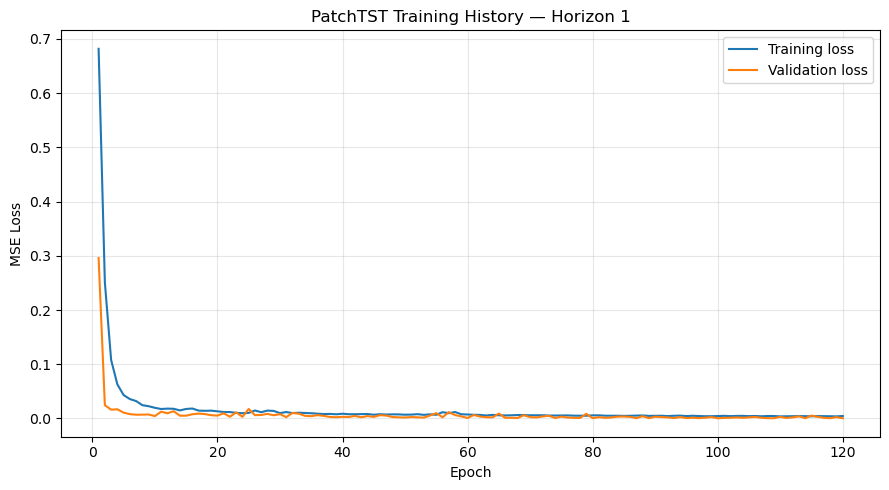

In [17]:
# ============================================================
# STEP 8B: Plot H=1 training history
# ============================================================

plot_training_history(
    history=history_h1,
    horizon=HORIZON
)

In [18]:
# ============================================================
# STEP 9: Test evaluation for H = 1
# ============================================================

def predict_model(
    model: nn.Module,
    data_loader: DataLoader,
    device: torch.device
):
    """
    Generate predictions and collect targets.

    Returns
    -------
    y_pred_scaled : np.ndarray
        Predictions in standardized units.

    y_true_scaled : np.ndarray
        Targets in standardized units.
    """

    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        for X_batch, y_batch in data_loader:

            X_batch = X_batch.to(device)

            batch_predictions = model(X_batch)

            predictions.append(
                batch_predictions.cpu().numpy()
            )

            targets.append(
                y_batch.numpy()
            )

    y_pred_scaled = np.concatenate(
        predictions,
        axis=0
    )

    y_true_scaled = np.concatenate(
        targets,
        axis=0
    )

    return y_pred_scaled, y_true_scaled


# ------------------------------------------------------------
# Generate H=1 test predictions
# ------------------------------------------------------------
y_pred_h1_scaled, y_true_h1_scaled = predict_model(
    model=patchtst_h1,
    data_loader=loaders[1]["test_loader"],
    device=device
)


print("Scaled prediction shape :", y_pred_h1_scaled.shape)
print("Scaled target shape     :", y_true_h1_scaled.shape)


# ------------------------------------------------------------
# Inverse-transform to the original km³ units
# ------------------------------------------------------------
y_pred_h1 = scaler.inverse_transform(
    y_pred_h1_scaled.reshape(-1, 1)
).reshape(y_pred_h1_scaled.shape)

y_true_h1 = scaler.inverse_transform(
    y_true_h1_scaled.reshape(-1, 1)
).reshape(y_true_h1_scaled.shape)


# ------------------------------------------------------------
# Test metrics
# ------------------------------------------------------------
rmse_h1 = np.sqrt(
    mean_squared_error(
        y_true_h1.reshape(-1),
        y_pred_h1.reshape(-1)
    )
)

mae_h1 = mean_absolute_error(
    y_true_h1.reshape(-1),
    y_pred_h1.reshape(-1)
)

r2_h1 = r2_score(
    y_true_h1.reshape(-1),
    y_pred_h1.reshape(-1)
)


print("\n" + "=" * 70)
print("PatchTST Test Results — 1-day Horizon")
print("=" * 70)

print(f"RMSE : {rmse_h1:.6f} km³")
print(f"MAE  : {mae_h1:.6f} km³")
print(f"R²   : {r2_h1:.6f}")

Scaled prediction shape : (2742, 1)
Scaled target shape     : (2742, 1)

PatchTST Test Results — 1-day Horizon
RMSE : 0.026156 km³
MAE  : 0.019190 km³
R²   : 0.999534


In [19]:
# ============================================================
# STEP 9B: Store H=1 results in memory
# ============================================================

patchtst_results = {}

patchtst_results[1] = {
    "rmse": rmse_h1,
    "mae": mae_h1,
    "r2": r2_h1,
    "best_epoch": best_epoch_h1,
    "best_val_loss": best_val_h1,
    "y_true": y_true_h1,
    "y_pred": y_pred_h1,
    "history": history_h1
}

print("H=1 results stored in patchtst_results[1].")

H=1 results stored in patchtst_results[1].


In [20]:
# ============================================================
# STEP 10: Train PatchTST for H = 7
# ============================================================

HORIZON = 7

set_seed(SEED)


patchtst_h7 = PatchTST(
    lookback=LOOKBACK,
    horizon=HORIZON,
    num_channels=1,
    patch_len=PATCH_LEN,
    stride=PATCH_STRIDE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    num_encoder_layers=N_ENCODER_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    padding_patch=True
).to(device)


parameter_count = sum(
    parameter.numel()
    for parameter in patchtst_h7.parameters()
    if parameter.requires_grad
)


print("=" * 70)
print("Training PatchTST — 7-day forecast horizon")
print("=" * 70)

print(f"Device             : {device}")
print(f"Lookback           : {LOOKBACK}")
print(f"Forecast horizon   : {HORIZON}")
print(f"Patch length       : {PATCH_LEN}")
print(f"Patch stride       : {PATCH_STRIDE}")
print(f"Number of patches  : {patchtst_h7.num_patches}")
print(f"d_model            : {D_MODEL}")
print(f"Attention heads    : {N_HEADS}")
print(f"Encoder layers     : {N_ENCODER_LAYERS}")
print(f"Trainable params   : {parameter_count:,}")


patchtst_h7, history_h7, best_epoch_h7, best_val_h7 = train_patchtst(
    model=patchtst_h7,
    train_loader=loaders[HORIZON]["train_loader"],
    val_loader=loaders[HORIZON]["val_loader"],
    device=device,
    learning_rate=1e-3,
    weight_decay=1e-4,
    max_epochs=200,
    patience=20,
    min_delta=1e-6,
    verbose_every=5
)

Training PatchTST — 7-day forecast horizon
Device             : cpu
Lookback           : 180
Forecast horizon   : 7
Patch length       : 16
Patch stride       : 8
Number of patches  : 22
d_model            : 64
Attention heads    : 4
Encoder layers     : 3
Trainable params   : 112,903
Epoch 001 | Train Loss: 0.734350 | Val Loss: 0.046420 | Best Val: 0.046420
Epoch 005 | Train Loss: 0.040950 | Val Loss: 0.017528 | Best Val: 0.017200
Epoch 010 | Train Loss: 0.024720 | Val Loss: 0.014326 | Best Val: 0.008997
Epoch 015 | Train Loss: 0.017333 | Val Loss: 0.006382 | Best Val: 0.006382
Epoch 020 | Train Loss: 0.014912 | Val Loss: 0.008563 | Best Val: 0.005615
Epoch 025 | Train Loss: 0.012133 | Val Loss: 0.005333 | Best Val: 0.004077
Epoch 030 | Train Loss: 0.009924 | Val Loss: 0.004315 | Best Val: 0.003514
Epoch 035 | Train Loss: 0.009455 | Val Loss: 0.003079 | Best Val: 0.003079
Epoch 040 | Train Loss: 0.009959 | Val Loss: 0.007636 | Best Val: 0.002361
Epoch 045 | Train Loss: 0.008515 | Val 

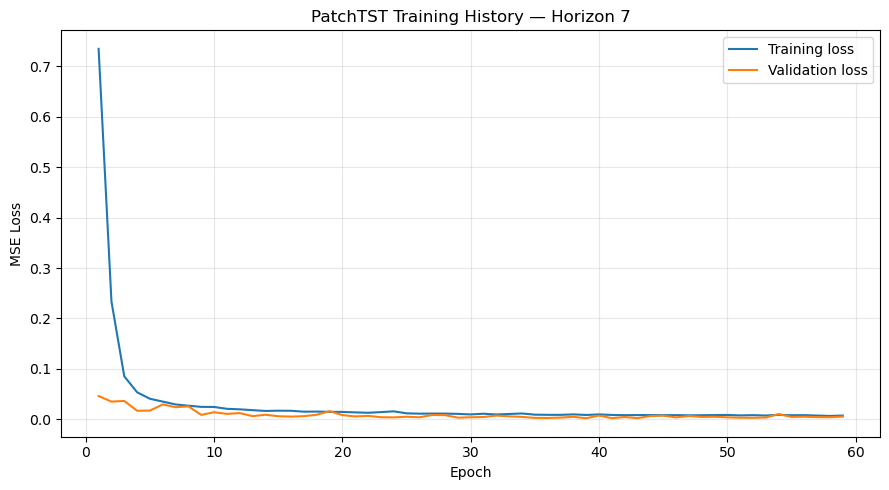

In [21]:
plot_training_history(
    history=history_h7,
    horizon=7
)

In [22]:
# ============================================================
# STEP 11: Test evaluation for H = 7
# ============================================================

y_pred_h7_scaled, y_true_h7_scaled = predict_model(
    model=patchtst_h7,
    data_loader=loaders[7]["test_loader"],
    device=device
)

print("Scaled prediction shape :", y_pred_h7_scaled.shape)
print("Scaled target shape     :", y_true_h7_scaled.shape)


# ------------------------------------------------------------
# Inverse-transform to original km³ units
# ------------------------------------------------------------
y_pred_h7 = scaler.inverse_transform(
    y_pred_h7_scaled.reshape(-1, 1)
).reshape(y_pred_h7_scaled.shape)

y_true_h7 = scaler.inverse_transform(
    y_true_h7_scaled.reshape(-1, 1)
).reshape(y_true_h7_scaled.shape)


# ------------------------------------------------------------
# Overall metrics across all samples and forecast steps
# ------------------------------------------------------------
rmse_h7 = np.sqrt(
    mean_squared_error(
        y_true_h7.reshape(-1),
        y_pred_h7.reshape(-1)
    )
)

mae_h7 = mean_absolute_error(
    y_true_h7.reshape(-1),
    y_pred_h7.reshape(-1)
)

r2_h7 = r2_score(
    y_true_h7.reshape(-1),
    y_pred_h7.reshape(-1)
)


print("\n" + "=" * 70)
print("PatchTST Test Results — 7-day Horizon")
print("=" * 70)

print(f"RMSE : {rmse_h7:.6f} km³")
print(f"MAE  : {mae_h7:.6f} km³")
print(f"R²   : {r2_h7:.6f}")

Scaled prediction shape : (2736, 7)
Scaled target shape     : (2736, 7)

PatchTST Test Results — 7-day Horizon
RMSE : 0.078928 km³
MAE  : 0.054044 km³
R²   : 0.995756


In [25]:
# ============================================================
# STEP 12: Train PatchTST for H = 30
# ============================================================

HORIZON = 30

set_seed(SEED)


patchtst_h30 = PatchTST(
    lookback=LOOKBACK,
    horizon=HORIZON,
    num_channels=1,
    patch_len=PATCH_LEN,
    stride=PATCH_STRIDE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    num_encoder_layers=N_ENCODER_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    padding_patch=True
).to(device)


parameter_count = sum(
    parameter.numel()
    for parameter in patchtst_h30.parameters()
    if parameter.requires_grad
)


print("=" * 70)
print("Training PatchTST — 30-day forecast horizon")
print("=" * 70)

print(f"Device             : {device}")
print(f"Lookback           : {LOOKBACK}")
print(f"Forecast horizon   : {HORIZON}")
print(f"Patch length       : {PATCH_LEN}")
print(f"Patch stride       : {PATCH_STRIDE}")
print(f"Number of patches  : {patchtst_h30.num_patches}")
print(f"d_model            : {D_MODEL}")
print(f"Attention heads    : {N_HEADS}")
print(f"Encoder layers     : {N_ENCODER_LAYERS}")
print(f"Trainable params   : {parameter_count:,}")


patchtst_h30, history_h30, best_epoch_h30, best_val_h30 = train_patchtst(
    model=patchtst_h30,
    train_loader=loaders[HORIZON]["train_loader"],
    val_loader=loaders[HORIZON]["val_loader"],
    device=device,
    learning_rate=1e-3,
    weight_decay=1e-4,
    max_epochs=200,
    patience=20,
    min_delta=1e-6,
    verbose_every=5
)

Training PatchTST — 30-day forecast horizon
Device             : cpu
Lookback           : 180
Forecast horizon   : 30
Patch length       : 16
Patch stride       : 8
Number of patches  : 22
d_model            : 64
Attention heads    : 4
Encoder layers     : 3
Trainable params   : 145,310
Epoch 001 | Train Loss: 0.739510 | Val Loss: 0.131459 | Best Val: 0.131459
Epoch 005 | Train Loss: 0.113019 | Val Loss: 0.182524 | Best Val: 0.131459
Epoch 010 | Train Loss: 0.080349 | Val Loss: 0.147035 | Best Val: 0.121670
Epoch 015 | Train Loss: 0.061134 | Val Loss: 0.145553 | Best Val: 0.110775
Epoch 020 | Train Loss: 0.052440 | Val Loss: 0.126654 | Best Val: 0.110775
Epoch 025 | Train Loss: 0.045468 | Val Loss: 0.181170 | Best Val: 0.110775
Epoch 030 | Train Loss: 0.038722 | Val Loss: 0.120051 | Best Val: 0.110775

Early stopping at epoch 32.

Best epoch: 12
Best validation loss: 0.110775


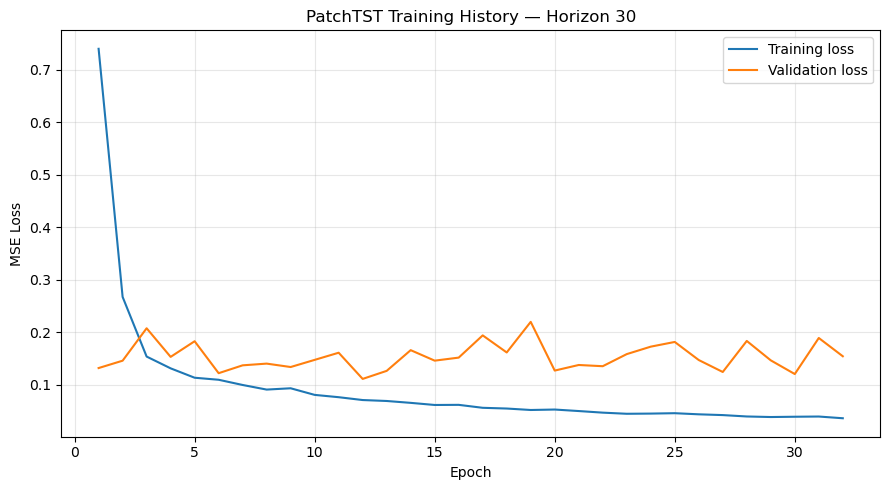

In [26]:
plot_training_history(
    history=history_h30,
    horizon=30
)

In [27]:
# ============================================================
# STEP 13: Test evaluation for H = 30
# ============================================================

y_pred_h30_scaled, y_true_h30_scaled = predict_model(
    model=patchtst_h30,
    data_loader=loaders[30]["test_loader"],
    device=device
)

print("Scaled prediction shape :", y_pred_h30_scaled.shape)
print("Scaled target shape     :", y_true_h30_scaled.shape)


# ------------------------------------------------------------
# Inverse-transform to original km³ units
# ------------------------------------------------------------
y_pred_h30 = scaler.inverse_transform(
    y_pred_h30_scaled.reshape(-1, 1)
).reshape(y_pred_h30_scaled.shape)

y_true_h30 = scaler.inverse_transform(
    y_true_h30_scaled.reshape(-1, 1)
).reshape(y_true_h30_scaled.shape)


# ------------------------------------------------------------
# Overall metrics across all samples and 30 forecast steps
# ------------------------------------------------------------
rmse_h30 = np.sqrt(
    mean_squared_error(
        y_true_h30.reshape(-1),
        y_pred_h30.reshape(-1)
    )
)

mae_h30 = mean_absolute_error(
    y_true_h30.reshape(-1),
    y_pred_h30.reshape(-1)
)

r2_h30 = r2_score(
    y_true_h30.reshape(-1),
    y_pred_h30.reshape(-1)
)


print("\n" + "=" * 70)
print("PatchTST Test Results — 30-day Horizon")
print("=" * 70)

print(f"RMSE : {rmse_h30:.6f} km³")
print(f"MAE  : {mae_h30:.6f} km³")
print(f"R²   : {r2_h30:.6f}")

Scaled prediction shape : (2713, 30)
Scaled target shape     : (2713, 30)

PatchTST Test Results — 30-day Horizon
RMSE : 0.449941 km³
MAE  : 0.320224 km³
R²   : 0.861578
